#  Disclaimer

The project uses a combination of publicly available Mosaic variables and a confidential donor dataset used in the consulting engagement.\
The dataset and empirical results cannot be shared.\
Certain dataset details, numerical values, and feature definitions have been partially redacted (****) to protect data confidentiality.\
The notebooks demonstrate the analytical workflow and modelling pipeline used in the project.


# Consulting Project EDA

This project will be focused on predicting donor **Life Time Value (target_2)**, defined as cumulative donation value over a future observation window. Understanding the logic and patterns is very important to determine the key factors that affect donors long-term behaviour.


## Section 2. Data Pre-processing

### 2.1 Data Overview
First, import libraries:

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

Next, load in the data:

In [ ]:
# 1. Load data

client = pd.read_csv('Client_TrainingSet.csv')

#### 2.1.1 General Information

In [ ]:
# 2. Quick view on dataset

client.head()

#### 2.1.2 Variable Types

In [ ]:
# 3. Info on data type, number of variables, and entries etc.

client.info()

In [ ]:
# 4. Summary of statistics

client.describe()

In [ ]:
# 5. Check missing values

client.isnull().sum().sort_values(ascending=False)

From data description above, we can see:
- This is a large dataset with **** entreis of data points;
- There are **** coloumns / variables;
- Most of them are objects, meaning data cleaning is required;
- A lot of data are missing, such as "feature_1", over ****% is ****, so data cleaning is required.


#### 2.1.3 Missing Value Overview

Let's zoom in on these columns with missing values:


In [ ]:
client["feature_1"].info()
print("-------------------")
client["feature_1"].unique()

In [ ]:
print(1-****/****)

Since there are only two objcets,[nan, 'Yes'], meaning "feature_1" col is very sparse, with only ****% "Yes". The rest are "NaN", which could be "No" by default, or failed to collect the data.

In [ ]:
client["feature_2"].info()
print("-------------------")
client["feature_2"].unique()

In [ ]:
print(1-****/****)

For feature_2, there are over **% missing values. By definition, the values represents "****". Hence, the Null values could suggest non-cash donation, or failing to report.

In [ ]:
client["feature_3"].info()
print("-------------------")
client["feature_3"].unique()

In [ ]:
print(1-****/****)

For feature_3, they defined 3 types and a prefer not to say option, but there are still ****% missing values. Since the options are quite covered, the rest could be seen as failling to input the response.


In [ ]:
client["feature_4"].info()
print("-------------------")
client["feature_4"].unique()

In [ ]:
print(1-****/****)

"feature_4" refers to "****". There are ****% missing values, however, from data description, ****. On the other hand, there are ****% are regular donors.

In [ ]:
client["feature_5"].info()
client["feature_5"].unique()

In [ ]:
print(1-****/****)

The feature_5 are simply refering to the feature_5, which could be outside of Australia (this is not good). The ****% missing values could be missed in collection, or the donor is unwilling to provide them.

In [ ]:
client["feature_6"].info()
print("-------------------")
client["feature_6"].unique()

In [ ]:
print(1-****/****)

In [ ]:
client["feature_6"].value_counts().head(20)

In [ ]:
client["feature_6"].value_counts().tail(10)

The "feature_6" is quite messy, as there are a lot of different feature_6s in full or abbreviations, and even noise data like numbers. Hence, cleaning is required by removing all the numerical numbers, then cleaning up the feature_6s. The ****% missing values could be missing from collection, as we could assume the question was presented as an open-end one, so people might not want to fill out a long answer, or simply input random numbers or words.

In [ ]:
client["feature_7"].info()
print("-------------------")
client["feature_7"].unique()

In [ ]:
print(1-****/****)

The unique values in "feature_7" represents **** etc, which seems correct. The missing values are only **%, which is a reasonable range for missing in collection.

### 2.2 Data Cleaning

#### 2.2.1 Unsignificant Variables
The following missing variables are determined as non-significant factors:
- **: index coloumn, no analytical meaning;
- ** internal client testing flag, it doesn’t add insight into donor behaviour.
  

In [ ]:
# Remove unsignificant missing variables
client_cleaned = client.drop(columns=["Unnamed: 0", "TestType"], errors="ignore")

#### 2.2.2 Missing Values  

The following variables contain missing values and are treated as follows:  

- **feature_1**: NaN means not an **** → recoded as `"No"`.  
- **feature_2**: NaN means donor never gave a **** → keep date, add `feature_8` flag (Yes/No).  
- **feature_4**: NaN means donor never became a **** → keep date, add `feature_9` flag(Yes/No).  
- **feature_3**: NaN means not disclosed → recoded as `"Unknown"`.  
- **feature_5**: NaN means not provided → recoded as `"Unknown"`.  
- **feature_6**: NaN means not provided → recoded as `"Unknown"`.  
- **feature_7**: NaN means not recorded → recoded as `"Unknown"`.  


In [ ]:
# feature_1: NaN → "No"
client_cleaned["feature_1"] = client_cleaned["feature_1"].fillna("No")

# feature_2: create flag for donors with cash gifts
client_cleaned["feature_8"] = client_cleaned["feature_2"].notna().astype(int)

# feature_4: create flag for donors with recurring gifts
client_cleaned["feature_9"] = client_cleaned["feature_4"].notna().astype(int)

# Demographics: feature_3, feature_5, feature_6 → NaN → "Unknown" (together)
for col in ["feature_3", "feature_5", "feature_6"]:
    client_cleaned[col] = client_cleaned[col].fillna("Unknown")

# Channel: feature_7 → NaN → "Unknown"
client_cleaned["feature_7"] = client_cleaned["feature_7"].fillna("Unknown")

client_cleaned.head()

#### 2.2.3 Specific Values

##### "feature_6" Cleaning

The `feature_6` variable contained inconsistent values, including valid feature_6s, variations in case, and foreign or miscoded entries (e.g., ).  

- All values were standardised to uppercase.  
- Valid feature_6 codes were retained.  
- Non-**** or miscoded entries were recoded as `"OTHER"`.  
- Missing values were recoded as `"UNKNOWN"`.  


In [ ]:
valid_feature_6s = {# Confidential data}
map_to_code = {
   # Confidential data
}

s = client_cleaned["feature_6"]
norm = s.astype(str).str.upper().str.strip()
mapped = norm.replace(map_to_code)

client_cleaned["feature_6"] = np.where(
    s.isna(), "UNKNOWN",                       # true missing
    np.where(mapped.isin(valid_feature_6s), mapped, "OTHER")  # not missing → code or OTHER
)

client_cleaned["feature_6"].unique()

In [ ]:
client_cleaned["feature_6"].value_counts().head(20)

In [ ]:
client_cleaned["feature_6"].notna().sum()

##### target_1 Cleaning  

The variable `target_1` contained negative values, which are not meaningful in the context of donations.  
These records were removed to ensure that only valid positive donations are included in the analysis.  


In [ ]:
# target_1 Cleaning

# Drop negative values
client_cleaned = client_cleaned[client_cleaned["target_1"] >= 0]


### 2.3 MOSAIC Data Integration

#### 2.3.1 Data Source and Content


We join MOSAIC by feature_5, as We retained both target_14 (broad lifestyle classification) and target_15 (dominant sub-segment) for feature engineering. While the dominant type does not always fall within the dominant group, this provides valuable nuance. For example, a feature_5 classified broadly as ‘Upscale Urbanites’ may still be dominated by a younger ‘Stylish Students’ segment, highlighting differences in potential donor behaviour.


In [ ]:
mosaic=pd.read_csv("MOSAIC.csv")
mosaic.head()

In [ ]:
mosaic['feature 11'].sum()

In [ ]:
mosaic_join=mosaic[['feature_5', 'feature 11', 'feature_6', 'feature 12','feature 13']]
mosaic_join.head()

#### 2.3.2 Joining Key and Process

To integrate the client donor dataset with the MOSAIC segmentation dataset, the feature_5 field is used as the joining key: 
- First, the feature_5 columns in both datasets are renamed consistently (e.g., feature_5 → feature_5) to avoid mismatches during merging. 
- A preliminary check is performed to ensure the column data types match (string vs. numeric) and to handle irregular formats (e.g., leading zeros, missing values). 
- The join is carried out using a left join (client as base, MOSAIC appended), ensuring that all client donors remain in the dataset, even if some feature_5s do not have a corresponding MOSAIC classification.


In [ ]:
# For MOSAIC dataset
mosaic_join = mosaic_join.rename(columns={
    'feature_5': 'feature_5',
    'feature_6': 'feature_6',
    'feature 12': 'Mosaic_Group',
    'feature 13': 'Mosaic_Type'
})

client_m = client_cleaned.rename(columns={
    'feature_5': 'feature_5',
    'feature_6': 'feature_6'
})
# Preview a few rows
client_m.head()

In [ ]:
# Convert feature_5 to string in both datasets for consistency
client_m['feature_5'] = client_m['feature_5'].fillna("Unknown").astype(str)
# Remove the '.0' if it exists
client_m['feature_5'] = client_m['feature_5'].str.replace(r'\.0$', '', regex=True)

# MOSAIC: convert to string too
mosaic_join['feature_5'] = mosaic_join['feature_5'].astype(str)

mosaic_join.info()
client_m.head()

In [ ]:
client_merged = pd.merge(
    client_m,
    mosaic_join,
    on='feature_5',
    how='left',
    suffixes=('_x','_y')
)
client_merged.head()

#### 2.3.3 Post-Join

After merging the client and MOSAIC datasets, duplicate fields such as feature_6_x (client) and feature_6_y (MOSAIC) were reconciled. Where feature_6_y was missing due to an unmatched or invalid feature_5, the value from feature_6_x was retained. This ensured that feature_6-level information was preserved even when donor feature_5s were incomplete or inaccurate.

In [ ]:
# Create unified feature_6 column
client_merged['feature_6'] = client_merged['feature_6_y'].fillna(client_merged['feature_6_x'])

# Drop old columns
client_merged = client_merged.drop(columns=['feature_6_x','feature_6_y'])

In [ ]:
client_merged['feature_6'].unique()

In [ ]:
client_merged.info()

## 3. Descriptive Statistics

This section summarises the distributions and general characteristics of key variables in the dataset, focusing on both numerical and categorical features.

### 3.1 Numerical Variables

The main continuous variables are `target_1` and `target_2`. The former serves as an important predictor, while the latter represents the target variable for the modelling task.

#### 3.1.1 Raw Data

We first examine the raw distributions of `target_1` and `target_2`. Both variables appear highly skewed, with most observations concentrated at relatively low values but a small number of larger observations in the upper tail. 

For `target_1`, the median value is relatively small compared to the mean, suggesting that a limited number of larger observations increase the overall average. A similar pattern is observed for `target_2`, where the distribution shows strong right-skewness, indicating that a small proportion of observations contribute disproportionately to the total value.

These characteristics suggest that transformations or robust modelling approaches may be necessary when incorporating these variables into predictive models.


In [ ]:
num_cols = ["target_1", "target_2"]

# Basic summary stats
summary_stats = client_merged[num_cols].describe().T

# Add skewness and kurtosis for each column
summary_stats["skewness"] = client_merged[num_cols].skew().values
summary_stats["kurtosis"] = client_merged[num_cols].kurt().values

# Round for readability
summary_stats = summary_stats.round(2)

print(summary_stats)

In [ ]:
# keep 
for col in ["target_1","target_2"]:
    cutoff = client_merged[col].quantile(0.99)
    **** = client_merged[client_merged[col] >= cutoff][col].sum()
    total = client_merged[col].sum()
    print(col, "****:", round(100*****/total,2), "%")

In [ ]:
# Define predictor (target_1) and target (target_2)
X = client_merged["target_1"]
y = client_merged["target_2"]

# Add constant for intercept
X = sm.add_constant(X)

# Fit regression
model = sm.OLS(y, X).fit()

print(model.summary())

#### 3.1.2 Log-Transformation

To address the high skewness, I introduced 2 methods. First is applying log transformation x_log=log(x+1): 

- **target_1_log**: compresses extreme donation values, making the distribution more symmetric.  
- **target_2_log**: reduces the influence of extreme outliers on predictive modelling.  

This transformation allows models to capture relative percentage differences rather than absolute dollar differences, which is very large as the below graphs shown. However, to ensure data accuracy, both raw and log-transformed values will be retained for future projects.

The OLS presents R^2 for log-transformed target_2 against target_1 is ****, which is a over ****% improvement comparing to raw data, suggesting log should be considered for future models. But for this EDA, will continue using raw and trimmed for average and graphical presentations.

In [ ]:
# Create log-transformed columns
client_merged["target_1_log"] = np.log1p(client_merged["target_1"])
client_merged["target_2_log"] = np.log1p(client_merged["target_2"])

fig, axes = plt.subplots(2, 2, figsize=(12,8))

# target_1 raw vs log
axes[0,0].hist(client_merged["target_1"], bins=100, color="lightblue", edgecolor="black")
axes[0,0].set_title("target_1 (Raw)")
axes[0,0].set_xlabel("target_1 (AUD)")
axes[0,0].set_ylabel("Frequency")

axes[0,1].hist(client_merged["target_1_log"], bins=100, color="skyblue", edgecolor="black")
axes[0,1].set_title("target_1 (Log Transformed)")
axes[0,1].set_xlabel("log(1 + target_1)")
axes[0,1].set_ylabel("Frequency")

# target_2 raw vs log
axes[1,0].hist(client_merged["target_2"], bins=100, color="lightgreen", edgecolor="black")
axes[1,0].set_title("target_2 (Raw)")
axes[1,0].set_xlabel("target_2 (AUD)")
axes[1,0].set_ylabel("Frequency")

axes[1,1].hist(client_merged["target_2_log"], bins=100, color="seagreen", edgecolor="black")
axes[1,1].set_title("target_2 (Log Transformed)")
axes[1,1].set_xlabel("log(1 + target_2)")
axes[1,1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
X_log = np.log1p(client_merged["target_1"])  # log(1+target_1)
X_log = sm.add_constant(X_log)

model_log = sm.OLS(y, X_log).fit()
print(model_log.summary())

#### 3.1.3 Trimmed Data

Another method is trimming the extreme data, I took 99th percentile as the benchmark and did winsorising. The statistic summary table presents the change: the mean for target_1 decreased, while the mean for target_2 dropped. All the quartiles remain unchanged. 

(Insights masked), reinforcing the importance of targeted segmentation in client’s fundraising strategy.

In [ ]:
# Columns to winsorise
num_cols = ["target_1", "target_2"]

for col in num_cols:
    if col in client_merged.columns:
        # Save original values
        client_merged[col + "_raw"] = client_merged[col]
        
        # Calculate 99th percentile cap
        cap = client_merged[col].quantile(0.99)
        
        # Apply winsorisation (cap upper tail)
        client_merged[col] = np.where(client_merged[col] > cap, cap, client_merged[col])
        
        print(f"{col}: values above {cap:.2f} capped at 99th percentile")

In [ ]:
num_cols = ["target_1", "target_2"]

# Basic summary stats
summary_stats = client_merged[num_cols].describe().T

# Add extra metrics: skewness and kurtosis
summary_stats["skewness"] = client_merged[num_cols].skew()
summary_stats["kurtosis"] = client_merged[num_cols].kurt()

# Round for readability
summary_stats = summary_stats.round(2)

print(summary_stats)

In [ ]:
num_cols = ["target_1", "target_2"]

fig, axes = plt.subplots(1, 2, figsize=(12,4))

for i, col in enumerate(num_cols):
    axes[i].hist(client_merged[col].dropna(), bins=50, color="skyblue", edgecolor="black")
    axes[i].set_title(f"Distribution of {col}", fontsize=12)
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

plt.suptitle("Histograms of Key Numerical Variables", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.show()

In [ ]:
num_cols = ["target_1", "target_2"]

fig, axes = plt.subplots(1, 2, figsize=(12,4))

for i, col in enumerate(num_cols):
    axes[i].boxplot(client_merged[col].dropna(),
                    vert=True,
                    patch_artist=True,       # fill with color
                    boxprops=dict(facecolor="lightblue", color="black"),
                    medianprops=dict(linewidth=2),
                    whiskerprops=dict(color="black"),
                    capprops=dict(color="black"),
                    flierprops=dict(marker='o', markerfacecolor='grey', markersize=4, alpha=0.5))
    
    axes[i].set_title(f"Boxplot of {col}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel(col, fontsize=10)
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

plt.suptitle("Boxplots of Key Numerical Variables", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 3.2 Categorical Variables  

The dataset includes several categorical features describing donor demographics and donation behaviours. Their distributions are summarised below.  

#### 3.2.1 Demographic Variables  
- **feature_3**: Majority female (41%) followed by male (35%), with a substantial share (~23%) of “Unknown” due to non-disclosure.
- **target_13**: Although almost 50% remains unknown, we can still observe donors' pattern are higher in the 31-50 feature_13, with substaintial smaller shares among older and younger segments.  
- **feature_6**: Donors are concentrated in NSW (34%) and VIC (23%). All feature_6s has been mapped against feature_5 after merging with MOSAIC. Non-Australian or invalid feature_6 entries have been removed as they are not this project's focus.
- **target_14**: Concentrated in Group A and B (25%), N has lowest number of donors.
- **target_15**: A02 is the dominating amongst the top 15 Mosaic_type.

In [ ]:
# Demographic variables
demo_cols = ["feature_3", "target_13", "feature_6"]

rows = math.ceil(len(demo_cols) / 3)
fig, axes = plt.subplots(rows, 3, figsize=(15, rows*4))
axes = axes.flatten()

for i, col in enumerate(demo_cols):
    value_counts = client_merged[col].value_counts(normalize=True) * 100
    value_counts.plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_ylabel("Percentage (%)")
    axes[i].tick_params(axis="x", rotation=45)

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [ ]:

# Distributions (percent)
group_counts = (client_merged["Mosaic_Group"]
                .value_counts(normalize=True)
                .mul(100)
                .sort_values(ascending=False))

type_counts = (client_merged["Mosaic_Type"]
               .value_counts(normalize=True)
               .mul(100)
               .sort_values(ascending=False)
               .head(15))  # top 10 types only

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Left: Groups
group_counts.plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title("target_14 Distribution")
axes[0].set_ylabel("Percentage (%)")
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right")

# Right: Top 10 Types
type_counts.plot(kind="bar", ax=axes[1], edgecolor="black")
axes[1].set_title("Top 15 target_15s Distribution")
axes[1].set_ylabel("Percentage (%)")
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.show()

#### 3.2.2 Donation Behaviour Variables  

- **Initial_90_Days_target_2**: Binary flag; a significant proportion of donors make no donations (80%) within the first 90 days.  
- **Pre_RG_Donation**: Binary flag; most donors made donations before converted to regular giving (85%).  
- **feature_7**: Most donations come from website (35%), with next runner F2F (23%) and Door to Door (18%) add up to similar portion.
- **ProductType_Group**: Most donations are recurring gifts (80%), and cash (10%).
- **CampaignSubtype_Group**: Campaigns are concentrated on Regular Giving (85%), with small portion of Appeal (10%, one off donations).  
- **feature_18**: Most donations are non-seasonal (93%), with very tiny margins being tax and Christmas seasonal (~5%).


In [ ]:
# Behavioural variables
behav_cols = [
    "Initial_90_Days_target_2", "Pre_RG_Donation", 
    "feature_7", "ProductType_Group", 
    "CampaignSubtype_Group", "feature_18"
]

rows = math.ceil(len(behav_cols) / 3)
fig, axes = plt.subplots(rows, 3, figsize=(18, rows*5))  # bigger figure

axes = axes.flatten()

for i, col in enumerate(behav_cols):
    value_counts = client_merged[col].value_counts(normalize=True) * 100
    value_counts.plot(kind="bar", ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_ylabel("Percentage (%)")
    
    # Rotate and align x-axis labels
    axes[i].tick_params(axis="x", rotation=30, labelsize=9)  
    for tick in axes[i].get_xticklabels():
        tick.set_horizontalalignment("right")

# Remove unused subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### 3.3 Analysis


In [ ]:
# Define threshold on raw target_2 
# Flag 
# Create side-by-side boxplots for target_2 and target_1

# target_2

# target_1

# Clean up
plt.suptitle("")  # remove automatic group title
plt.tight_layout()
plt.show()

In [ ]:
# 1) Define ****Donors 

# 2) Ensure correct column names

# 3) Build distributions (drop NaNs)

# 4) Guard
    # Left: Group
    # Right: Top 15 Types

    plt.show()

### 3.4 Bivariate Analysis

#### 3.4.1 Numerical-Numerical


In [ ]:
# Using the unique ID, filter out the ****
# Correlation

In [ ]:

# Add a simple regression line
plt.show()

In [ ]:
# Frequency 
# Correlation
print("Correlation:", .corr())

# Scatter plot


#### 3.4.2 Numerical-Categorical

##### feature_6 vs. target_1/target_2



In [ ]:
# Aggregate averages
# Plot side by side

# Left: target_1

# Right: target_2
plt.show()

In [ ]:
from scipy.stats import f_oneway

groups = [client_merged.loc[client_merged["feature_6"]==s, "target_2_raw"].dropna()
          for s in client_merged["feature_6"].unique()]
f_stat, p_val = f_oneway(*groups)
print("ANOVA F-stat:", f_stat, "p-value:", p_val.round(2))

##### feature_3 vs. target_1/target_2


- **target_1**: 
- **target_2**: 
- One-way ANOVA confirms significant 


In [ ]:
# Average target_1 by feature_3 (all categories)
# Average target_2 by feature_3 (all categories)

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# target_1

# target_2
plt.show()

In [ ]:
# Keep only
# Average target_1 by feature_3
# Average target_2 by feature_3
# Side-by-side plots
# target_1
# target_2

plt.show()


In [ ]:
# One-way ANOVA
groups = [group["target_2_raw"].dropna() 
          for name, group in client_merged.groupby("feature_3")]
print(f_oneway(*groups))

##### vs. target_1/target_2

- **target_1**: 
- **target_2**:
- F-Test (one way anova) has p-value of 0, suggesting relationship is signifcant.

In [ ]:
# Remove "Unknown" for plot here
# Average target_1 by target_13
# Average target_2 by target_13
# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# target_1 plot
# target_2 plot

plt.show()

In [ ]:

# One-way ANOVA (example for target_2)
groups = [
    group["target_2_raw"].dropna()
    for name, group in client_merged.groupby("target_13")
]
anova_result = f_oneway(*groups)
print("ANOVA p-value for target_2 across:", anova_result)


##### target_14 vs. target_1/target_2
- Average target_1: 
- Average target_2: 

In [ ]:
# Average target_1 by target_14
group_gift = client_merged.groupby("Mosaic_Group")["target_1"].mean().sort_values(ascending=False)

# Average target_2 by target_14
group_target_2 = client_merged.groupby("Mosaic_Group")["target_2"].mean().sort_values(ascending=False)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# target_1 plot

# target_2 plot
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


##### target_15 vs. target_1/target_2
- Average target_1: 
- Average target_2: 

In [ ]:
# Top 20 target_15s by mean target_1
# Top 20 target_15s by mean target_2

plt.show()

##### feature_7 vs. target_1/target_2
- Average target_1: 
- Average target_2: 

In [ ]:
# Mean target_1 by channel
# Mean target_2 by channel
fig, axes = plt.subplots(1, 2, figsize=(16,6))


plt.tight_layout()
plt.show()


##### feature_15 vs. target_1/target_2


- **target_1**
- **target_2**: 
- **Lowest Values**:


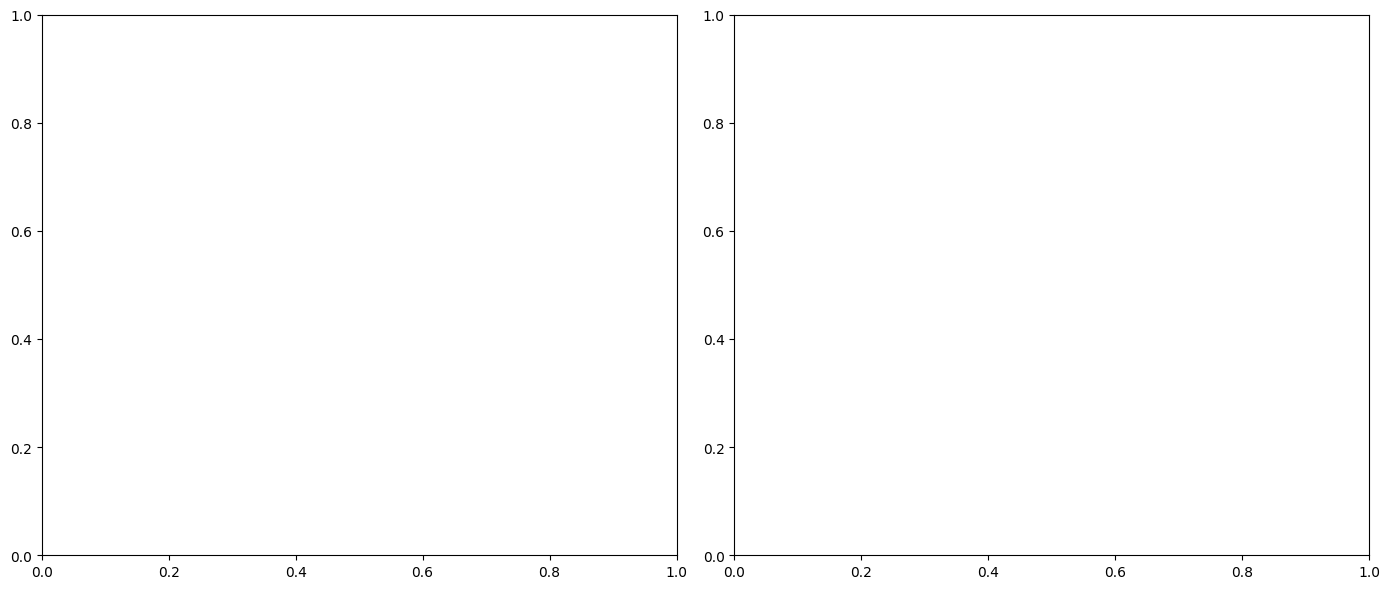

In [4]:
# Group averages
# Create side-by-side barplots
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# target_1 (lightblue)
# target_2 (default colour)
plt.tight_layout()
plt.show()


##### feature_16 vs. Gift/target_2


##### feature_17 vs. Gift/target_2


#### 3.4.3 Categorical-Categorical

##### feature_3 vs. target_13



In [ ]:
pd.crosstab(client_merged["target_13"], client_merged["feature_3"], normalize="index").plot(
    kind="bar", stacked=True, figsize=(10,6), colormap="Paired"
)
plt.title("feature_3 Distribution across feature_13")
plt.ylabel("Proportion within ")
plt.xlabel(" "")
plt.show()


##### target_13 vs. 

##### target_14 vs. feature_7


In [ ]:
# Cross-tab between target_14 and Channel
# Convert to row-wise proportions
# Plot stacked bars

In [ ]:
chi2, p, dof, expected = chi2_contingency(cross_tab)
print(f"Chi-square: {chi2:,.0f} | dof: {dof} | p-value: {p:.3e}")

##### target_15 vs. feature_7


In [ ]:
# Cross-tab between target_15

# Normalise row-wise (proportion within type)

# Focus on Top 20 target_15s 
# Heatmap

##### feature_16 vs. feature_19

The Chi-square test for independence show a ...

##### feature_17 vs. feature_19


In [ ]:

# Cross-tab feature_17 vs Channel
# Stacked bar

In [ ]:
# Crosstab (counts)
cross_tab = pd.crosstab(client_merged["feature_17"], client_merged["feature_7"])

# Chi-square test

#### 3.5 Seasonality:  


In [ ]:

# Ensure datetime

# Extract year-month

# Count new donors per month

# Plot

### 4. Feature Engineering

#### 4.1 Designed_Feature_1


In [ ]:
# Ensure feature is datetime
# Rebuild donor_features cleanly

# Add Designed_Feature_1 column
print(donor_features.head())
print(donor_features.columns)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Designed_Feature_1 vs Total target_1
axes[0].set_yscale("log")  # log y for skew

# Designed_Feature_1 vs target_2
plt.tight_layout()
plt.show()

In [ ]:
# Create log-transformed variables (+1 to avoid log(0))
donor_features["log_Designed_Feature_1"] = np.log1p(donor_features["Designed_Feature_1"])
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Log Designed_Feature_1 vs Log Total target_1
sns.regplot(
    x="log_Designed_Feature_1", y="log_Total_Gift_Amount", data=donor_features,
    scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'},
    ax=axes[0]
)
axes[0].set_title("Log–Log: Designed_Feature_1 vs Total target_1 (OLS Fit)")
axes[0].set_xlabel("log(1 + Designed_Feature_1)")
axes[0].set_ylabel("log(1 + Total target_1)")

# Log Designed_Feature_1 vs Log target_2
sns.regplot(
    x="log_Designed_Feature_1", y="log_target_2", data=donor_features,
    scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'},
    ax=axes[1]
)
axes[1].set_title("Log–Log: Designed_Feature_1 vs target_2 (OLS Fit)")
axes[1].set_xlabel("log(1 + Designed_Feature_1)")
axes[1].set_ylabel("log(1 +   target_2)")

plt.tight_layout()
plt.show()


In [ ]:

# Drop missing values to avoid errors
df = donor_features.dropna(subset=["Designed_Feature_1_days", "Total_Gift_Amount", "target_2"])

#  Model 1: Designed_Feature_1 vs Total target_1 
X1 = sm.add_constant(df["Designed_Feature_1_days"])   # Independent variable (with intercept)
y1 = df["Total_Gift_Amount"]              # Dependent variable

model1 = sm.OLS(y1, X1).fit()
print("OLS: Designed_Feature_1 vs Total target_1")
print(model1.summary())

#  Model 2: Designed_Feature_1 vs target_2 
X2 = sm.add_constant(df["Designed_Feature_1_days"])
y2 = df["target_2"]

model2 = sm.OLS(y2, X2).fit()
print("\nOLS: Designed_Feature_1 vs target_2")
print(model2.summary())


In [ ]:
# Drop NA to avoid errors
df = donor_features.dropna(subset=["Designed_Feature_1_days", "Total_Gift_Amount", "target_2"]).copy()

# Log-transform (log1p avoids log(0))
df["log_Designed_Feature_1"] = np.log1p(df["Designed_Feature_1_days"])
df["log_Total_Gift_Amount"] = np.log1p(df["Total_Gift_Amount"])
df["log_target_2"] = np.log1p(df["target_2"])

# --- Model 1: log(Designed_Feature_1) vs log(Total target_1) ---
X1 = sm.add_constant(df["log_Designed_Feature_1"])
y1 = df["log_Total_Gift_Amount"]
model1_log = sm.OLS(y1, X1).fit()
print("Log-Log OLS: Designed_Feature_1 vs Total target_1")
print(model1_log.summary())

# --- Model 2: log(Designed_Feature_1) vs log(target_2) ---
X2 = sm.add_constant(df["log_Designed_Feature_1"])
y2 = df["log_target_2"]
model2_log = sm.OLS(y2, X2).fit()
print("\nLog-Log OLS: Designed_Feature_1 vs target_2")
print(model2_log.summary())

## 4.2 Behavioural Aggregates

- Total Gift Counts per Donor: 
- Average target_1 per Donor: 


In [ ]:
# Aggregate donor-level features 

print(donor_features.head())

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Total target_1 (frequency distribution)

# Average target_1 (distribution)

# Total target_1 vs target_2 (scatter, log-log)

# Average target_1 vs target_2 (scatter, log-log)
plt.tight_layout()
plt.show()

#### 4.3 Log Transformation
Many behavioural and value-based features in the dataset (e.g., target_1, target_2, Average target_1, Total target_1) are ...
To address this, we apply a logarithmic transformation of the form: x_log = log(x+1)